# Pre-processing: GHS-SMOD urban / rural raster

Stream the JRC Global Human Settlement Layer **SMOD** product, clip it to an AOI, and reclassify it into a single Urban / Rural / nodata raster. Mirrors the AOI used in `1_worldpop_pre_processing.ipynb` so the two outputs share a footprint.

## 1. Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

from d_health import GHSSmodConfig, get_smod_data
from d_health.io import load_raster

c:\Users\athanasi\Project_files\1_Projects_SITO\Health\D-Health_Tool\d_health\.pixi\envs\default\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


## 2. Configure the run

Same Paramaribo bounding box as `1_worldpop_pre_processing.ipynb`, so the SMOD output shares the AOI footprint with the population raster. `cfg` defaults to the 2025 epoch, R2023A release, 30 arc-second (~1 km) global product in EPSG:4326 — i.e. the file `GHS_SMOD_E2025_GLOBE_R2023A_4326_30ss_V2_0.tif`.

In [2]:
output_dir = Path("./data")
smod_path = output_dir / "sur_urban_rural.nc"

# Paramaribo bounding box in EPSG:4326 (xmin, ymin, xmax, ymax) — same as the population notebook.
paramaribo_bounds = (-55.27, 5.78, -55.10, 5.93)

## 3. Fetch and reclassify

`get_smod_data` streams the global SMOD ZIP from the JRC open-data server into a temp directory, extracts the GeoTIFF, masks it to `paramaribo_bounds`, and reclassifies in memory. The ZIP and the global-extent TIF are deleted before the call returns — only the reclassified raster lands at `smod_path`:

| Output | Meaning | Source SMOD classes |
|---|---|---|
| `1` | Urban  | 30, 23, 22, 21 |
| `2` | Rural  | 13, 12, 11 |
| `0` | nodata | water (10) + pixels outside the AOI |

In [3]:
raster_path = get_smod_data(
    smod_path,
    clip=paramaribo_bounds,
)
raster_path

d_health.preprocessing.smod | INFO | GHS-SMOD R2023A E2025 (4326, 30ss) — clip=yes
d_health.preprocessing.smod | INFO | Downloading https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/GHSL/GHS_SMOD_GLOBE_R2023A/GHS_SMOD_E2025_GLOBE_R2023A_4326_30ss/V2-0/GHS_SMOD_E2025_GLOBE_R2023A_4326_30ss_V2_0.zip
d_health.preprocessing.smod | INFO | Saved GHS_SMOD_E2025_GLOBE_R2023A_4326_30ss_V2_0.zip (34.0 MB)
d_health.preprocessing.smod | INFO | Extracted GHS_SMOD_E2025_GLOBE_R2023A_4326_30ss_V2_0.tif
d_health.io | INFO | Wrote sur_urban_rural.nc (1 variable(s))
d_health.preprocessing.smod | INFO | Wrote sur_urban_rural.nc (19 × 21, urban=193 rural=128 nodata=78, 0.01 MB)


WindowsPath('data/sur_urban_rural.nc')

## 4. Inspect the output

Sanity-check: single layer with only values `{0, 1, 2}`, nodata = 0.

In [4]:
ur = load_raster(raster_path)
print("CRS:    ", ur.rio.crs)
print("Shape:  ", dict(ur.sizes))
print("Dtype:  ", ur.dtype)
print("NoData: ", ur.rio.nodata)

# nodata may decode to NaN on read; treat NaN as 0 for the value tally.
arr = np.nan_to_num(ur.values, nan=0).astype("uint8")

unique, counts = np.unique(arr, return_counts=True)
labels = {0: "nodata", 1: "urban", 2: "rural"}
print("\nPixel counts:")
for value, count in zip(unique, counts):
    pct = 100 * count / arr.size
    print(f"  {value} ({labels.get(int(value), '?')}): {count:>8,} ({pct:5.1f}%)")

assert set(unique.tolist()) <= {0, 1, 2}, unique

CRS:     EPSG:4326
Shape:   {'y': 19, 'x': 21}
Dtype:   float32
NoData:  nan

Pixel counts:
  0 (nodata):       78 ( 19.5%)
  1 (urban):      193 ( 48.4%)
  2 (rural):      128 ( 32.1%)


## 5. Visualise

Discrete colormap — light grey for nodata, red for urban, green for rural.

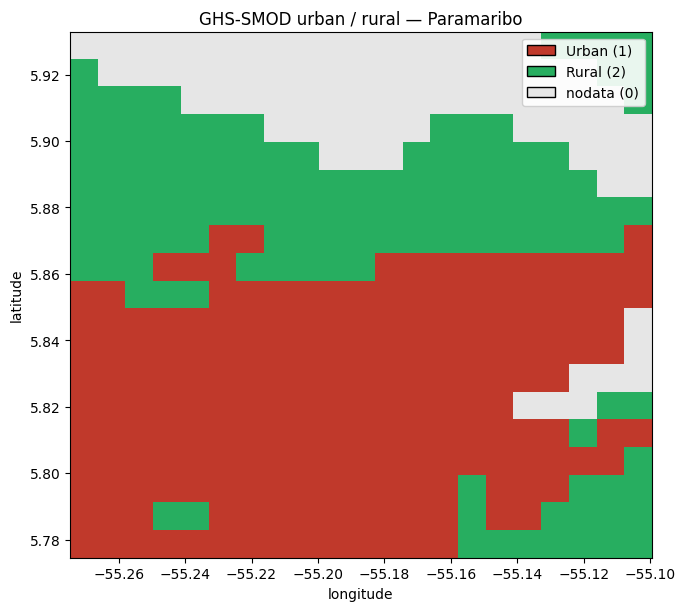

In [5]:
colors = {0: "#e6e6e6", 1: "#c0392b", 2: "#27ae60"}
cmap = ListedColormap([colors[0], colors[1], colors[2]])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

left, bottom, right, top = ur.rio.bounds()

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
ax.imshow(
    arr, cmap=cmap, norm=norm,
    extent=(left, right, bottom, top),
)
ax.set_title(f"GHS-SMOD urban / rural — Paramaribo")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")

legend = [
    Patch(facecolor=colors[1], edgecolor="black", label="Urban (1)"),
    Patch(facecolor=colors[2], edgecolor="black", label="Rural (2)"),
    Patch(facecolor=colors[0], edgecolor="black", label="nodata (0)"),
]
ax.legend(handles=legend, loc="upper right", framealpha=0.9)
plt.show()